<a href="https://colab.research.google.com/github/Beki1737/Beki1737/blob/main/NYC_taxi_trip_Data_analysis_with_spark_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NYC Taxi Trip Data Analysis with PySpark

This notebook implements Problem 2: Analyzing NYC Taxi Trip Data to Predict Fare Amount **Tasks 1–7** of the NYC Taxi assignment using **PySpark** and **Google Colab**.  
The pipeline uses **Parquet** as the main storage format for all cleaned and feature-engineered data, with CSV only used in Task 1 to compare disk space.

---

## Setup & Paths

In this section, we:

- Mount Google Drive
- Define a consistent project folder: `/content/drive/MyDrive/nyc_taxi_project`
- Create subfolders for:
  - Raw CSV and Parquet
  - Cleaned Parquet
  - SQLite databases
  - Feature-engineered data
- Start a `SparkSession` to use PySpark for all tasks


In [ ]:
# =====================================================
# Task 1 – Data Download and Parquet → CSV Conversion
# NYC TLC Yellow & Green Taxi Trip Records (2020–2024)
# =====================================================

# 1) Install & import dependencies
!pip install -q pyspark

import os
from pathlib import Path
import requests
from pyspark.sql import SparkSession

# 2) Mount Google Drive (for persistent storage)
from google.colab import drive
drive.mount('/content/drive')

# 3) Define project root on Google Drive
PROJECT_ROOT = "/content/drive/MyDrive/nyc_taxi_project"

RAW_PARQUET_DIR   = os.path.join(PROJECT_ROOT, "data_raw", "parquet")
RAW_CSV_DIR       = os.path.join(PROJECT_ROOT, "data_raw", "csv")

for taxi in ["yellow", "green"]:
    os.makedirs(os.path.join(RAW_PARQUET_DIR, taxi), exist_ok=True)
    os.makedirs(os.path.join(RAW_CSV_DIR, taxi), exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_PARQUET_DIR:", RAW_PARQUET_DIR)
print("RAW_CSV_DIR:", RAW_CSV_DIR)

# 4) Start Spark session
spark = (
    SparkSession.builder
    .appName("NYC_Taxi_Task1_Download_Convert")
    .master("local[*]")
    .getOrCreate()
)

spark


Mounted at /content/drive
PROJECT_ROOT: /content/drive/MyDrive/nyc_taxi_project
RAW_PARQUET_DIR: /content/drive/MyDrive/nyc_taxi_project/data_raw/parquet
RAW_CSV_DIR: /content/drive/MyDrive/nyc_taxi_project/data_raw/csv


## Task 1 – Download & Convert (Parquet vs CSV size)

**Goal:**

1. Download the NYC TLC Yellow and Green taxi trip data (2020–2024) as **Parquet** files.
2. Convert each monthly Parquet file to CSV to compare disk usage.
3. Show:
   - Number of Parquet files per taxi type
   - Number of monthly CSV directories per taxi type
   - Disk usage of Parquet vs CSV

**Notes:**

- The Parquet files are the *primary* source for all later tasks.
- The CSV conversion is only used to illustrate that CSV takes more space than Parquet, as required in the assignment.
- The code is idempotent: if files/folders already exist, it will skip re-downloading or re-converting.


In [ ]:
# 5) Helpers for URLs and local paths

BASE_URL = "https://d37ci6vzurychx.cloudfront.net/trip-data"

def parquet_path(taxi_type: str, year: int, month: int) -> str:
    """
    Local parquet path on Drive for a given taxi_type/year/month.
    """
    fname = f"{taxi_type}_tripdata_{year}-{month:02d}.parquet"
    return os.path.join(RAW_PARQUET_DIR, taxi_type, fname)

def csv_out_dir(taxi_type: str, year: int, month: int) -> str:
    """
    Local CSV output directory on Drive for a given taxi_type/year/month.
    Spark will write one or more part-*.csv files into this folder.
    """
    return os.path.join(
        RAW_CSV_DIR,
        taxi_type,
        f"{taxi_type}_tripdata_{year}-{month:02d}_csv"
    )

def tlc_url(taxi_type: str, year: int, month: int) -> str:
    """
    CloudFront URL for NYC TLC trip data parquet.
    """
    return f"{BASE_URL}/{taxi_type}_tripdata_{year}-{month:02d}.parquet"


In [ ]:
# 6) Download parquet if needed (resumable)

def download_parquet_if_needed(taxi_type: str, year: int, month: int):
    """
    Download the parquet file for (taxi_type, year, month) if not already present.
    Returns the local parquet path or None if download failed.
    """
    assert taxi_type in ["yellow", "green"]

    dest = parquet_path(taxi_type, year, month)
    dest_path = Path(dest)

    if dest_path.exists():
        print(f"[SKIP DOWNLOAD] {taxi_type} {year}-{month:02d} already exists: {dest}")
        return dest

    url = tlc_url(taxi_type, year, month)
    print(f"[DOWNLOAD] {url} -> {dest}")

    try:
        resp = requests.get(url, stream=True, timeout=120)
    except Exception as e:
        print(f"[ERROR] Request failed for {url}: {e}")
        return None

    if resp.status_code != 200:
        print(f"[WARN] Could not download {url} (HTTP {resp.status_code})")
        return None

    dest_path.parent.mkdir(parents=True, exist_ok=True)
    with open(dest, "wb") as f:
        for chunk in resp.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)

    print(f"[OK] Downloaded {taxi_type} {year}-{month:02d}")
    return dest


In [ ]:
# 7) Convert parquet → CSV (resumable)

from pyspark.sql import DataFrame

def convert_parquet_to_csv_if_needed(taxi_type: str, year: int, month: int):
    """
    Read the monthly parquet with Spark and write it to CSV (with header),
    unless CSV already exists.
    """
    src = parquet_path(taxi_type, year, month)
    out_dir = csv_out_dir(taxi_type, year, month)

    src_path = Path(src)
    out_path = Path(out_dir)

    if not src_path.exists():
        print(f"[SKIP CONVERT] Parquet missing for {taxi_type} {year}-{month:02d}: {src}")
        return

    # If CSV output folder exists and is non-empty, skip
    if out_path.exists() and any(out_path.iterdir()):
        print(f"[SKIP CONVERT] CSV already exists for {taxi_type} {year}-{month:02d}: {out_dir}")
        return

    print(f"[CONVERT] {src} -> {out_dir}")
    df: DataFrame = spark.read.parquet(src)

    # Write as CSV with header; will create multiple part-*.csv files inside out_dir
    (df.write
       .mode("overwrite")
       .option("header", True)
       .csv(out_dir))

    print(f"[OK] Converted {taxi_type} {year}-{month:02d} to CSV at {out_dir}")


In [ ]:
# 8) Main loop for Task 1: download + convert (2020–2024, Yellow & Green)

years = list(range(2020, 2025))   # 2020–2024 inclusive
months = list(range(1, 13))       # 1–12
taxi_types = ["yellow", "green"]

for taxi in taxi_types:
    for y in years:
        for m in months:
            print("=" * 80)
            print(f"{taxi.upper()} {y}-{m:02d}")
            print("-" * 80)
            parquet_file = download_parquet_if_needed(taxi, y, m)
            if parquet_file is not None:
                convert_parquet_to_csv_if_needed(taxi, y, m)

print("\n[Task 1] Download + Parquet→CSV conversion loop finished.")


YELLOW 2020-01
--------------------------------------------------------------------------------
[DOWNLOAD] https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2020-01.parquet -> /content/drive/MyDrive/nyc_taxi_project/data_raw/parquet/yellow/yellow_tripdata_2020-01.parquet
[OK] Downloaded yellow 2020-01
[CONVERT] /content/drive/MyDrive/nyc_taxi_project/data_raw/parquet/yellow/yellow_tripdata_2020-01.parquet -> /content/drive/MyDrive/nyc_taxi_project/data_raw/csv/yellow/yellow_tripdata_2020-01_csv
[OK] Converted yellow 2020-01 to CSV at /content/drive/MyDrive/nyc_taxi_project/data_raw/csv/yellow/yellow_tripdata_2020-01_csv
YELLOW 2020-02
--------------------------------------------------------------------------------
[DOWNLOAD] https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2020-02.parquet -> /content/drive/MyDrive/nyc_taxi_project/data_raw/parquet/yellow/yellow_tripdata_2020-02.parquet
[OK] Downloaded yellow 2020-02
[CONVERT] /content/drive/MyDrive/nyc_taxi

In [ ]:
# 9) Quick sanity check: count parquet & CSV monthly folders

import glob

yellow_parquet_files = glob.glob(os.path.join(RAW_PARQUET_DIR, "yellow", "*.parquet"))
green_parquet_files  = glob.glob(os.path.join(RAW_PARQUET_DIR, "green", "*.parquet"))

yellow_csv_dirs = glob.glob(os.path.join(RAW_CSV_DIR, "yellow", "*_csv"))
green_csv_dirs  = glob.glob(os.path.join(RAW_CSV_DIR, "green", "*_csv"))

print("Yellow parquet files:", len(yellow_parquet_files))
print("Green parquet files :", len(green_parquet_files))
print("Yellow CSV monthly dirs:", len(yellow_csv_dirs))
print("Green CSV monthly dirs :", len(green_csv_dirs))

# Show a small sample from one CSV folder to confirm structure
if yellow_csv_dirs:
    sample_csv_dir = yellow_csv_dirs[0]
    print("\nSample Yellow CSV directory:", sample_csv_dir)
    sample_df = spark.read.csv(sample_csv_dir, header=True, inferSchema=True)
    sample_df.show(5)


Yellow parquet files: 60
Green parquet files : 60
Yellow CSV monthly dirs: 60
Green CSV monthly dirs : 60

Sample Yellow CSV directory: /content/drive/MyDrive/nyc_taxi_project/data_raw/csv/yellow/yellow_tripdata_2020-01_csv
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|airport_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+----------

## Task 2 – Cleaning Data (Parquet)

**Goal:**

- Load the raw monthly taxi trip data (from CSV generated in Task 1).
- Cast all relevant columns to appropriate types.
- Parse pickup and dropoff timestamps.
- Compute `trip_duration_min` in minutes.
- Remove clearly invalid or inconsistent trips (e.g., non-positive distance or fare, zero/negative duration, extreme distances).
- Save the cleaned datasets as **Parquet**:

  - `data_clean/parquet/yellow`
  - `data_clean/parquet/green`

**Important:**

- After this task, **all subsequent analysis (Tasks 3–6) will use the cleaned Parquet files**.
- If the cleaned Parquet already exists, the notebook simply loads it and prints some statistics (this avoids re-running the long cleaning job).


In [ ]:
# =====================================================
# Task 2 – Data Processing & Cleaning with PySpark
# =====================================================

!pip install -q pyspark

import os
from pathlib import Path
from pyspark.sql import SparkSession, DataFrame
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType

# 1) Mount Google Drive (if not already)
from google.colab import drive
drive.mount('/content/drive')

# 2) Define paths (must match Task 1)
PROJECT_ROOT = "/content/drive/MyDrive/nyc_taxi_project"

RAW_CSV_DIR       = os.path.join(PROJECT_ROOT, "data_raw", "csv")
CLEAN_PARQUET_DIR = os.path.join(PROJECT_ROOT, "data_clean", "parquet")
os.makedirs(os.path.join(CLEAN_PARQUET_DIR, "yellow"), exist_ok=True)
os.makedirs(os.path.join(CLEAN_PARQUET_DIR, "green"), exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_CSV_DIR:", RAW_CSV_DIR)
print("CLEAN_PARQUET_DIR:", CLEAN_PARQUET_DIR)

# 3) Start / reuse Spark session
spark = (
    SparkSession.builder
    .appName("NYC_Taxi_Task2_Cleaning")
    .master("local[*]")
    .getOrCreate()
)

# Make datetime parsing robust
spark.conf.set("spark.sql.legacy.timeParserPolicy", "LEGACY")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_ROOT: /content/drive/MyDrive/nyc_taxi_project
RAW_CSV_DIR: /content/drive/MyDrive/nyc_taxi_project/data_raw/csv
CLEAN_PARQUET_DIR: /content/drive/MyDrive/nyc_taxi_project/data_clean/parquet


In [ ]:
# 4) Load & prepare Yellow CSVs (2020–2024)

def load_and_prepare_yellow() -> DataFrame:
    """
    Load ALL Yellow monthly CSVs from Drive, parse timestamps,
    and cast numeric columns.
    """
    path_pattern = os.path.join(RAW_CSV_DIR, "yellow", "*_csv", "*.csv")
    print(f"[RELOAD] Yellow from {path_pattern}")

    # Read everything as strings, then cast manually (more robust)
    df = (
        spark.read
        .option("header", True)
        .option("inferSchema", False)
        .csv(path_pattern)
    )
    print("[YELLOW] Schema before:")
    df.printSchema()

    # Rename original datetime columns
    df = df.withColumnRenamed("tpep_pickup_datetime", "pickup_raw") \
           .withColumnRenamed("tpep_dropoff_datetime", "dropoff_raw")

    # Normalize timestamps:
    #  - replace 'T' with space (if any)
    #  - remove fractional seconds like .000 or .123
    df = df.withColumn(
            "pickup_clean",
            F.regexp_replace(
                F.regexp_replace("pickup_raw", "T", " "),
                "\\.\\d+$", ""
            )
        ).withColumn(
            "dropoff_clean",
            F.regexp_replace(
                F.regexp_replace("dropoff_raw", "T", " "),
                "\\.\\d+$", ""
            )
        )

    # Parse to proper timestamp
    df = df.withColumn(
            "pickup_datetime",
            F.to_timestamp("pickup_clean", "yyyy-MM-dd HH:mm:ss")
        ).withColumn(
            "dropoff_datetime",
            F.to_timestamp("dropoff_clean", "yyyy-MM-dd HH:mm:ss")
        )

    # Drop helper columns
    df = df.drop("pickup_raw", "dropoff_raw", "pickup_clean", "dropoff_clean")

    # Cast numeric columns
    numeric_cols = [
        "passenger_count", "trip_distance", "RatecodeID",
        "PULocationID", "DOLocationID", "payment_type",
        "fare_amount", "extra", "mta_tax", "tip_amount",
        "tolls_amount", "improvement_surcharge",
        "total_amount", "congestion_surcharge", "airport_fee"
    ]
    for c in numeric_cols:
        if c in df.columns:
            df = df.withColumn(c, F.col(c).cast(DoubleType()))

    print("[YELLOW] Schema after:")
    df.printSchema()
    return df


In [ ]:
# 5) Load & prepare Green CSVs (2020–2024)

def load_and_prepare_green() -> DataFrame:
    """
    Load ALL Green monthly CSVs from Drive, parse timestamps,
    and cast numeric columns.
    """
    path_pattern = os.path.join(RAW_CSV_DIR, "green", "*_csv", "*.csv")
    print(f"[RELOAD] Green from {path_pattern}")

    df = (
        spark.read
        .option("header", True)
        .option("inferSchema", False)
        .csv(path_pattern)
    )
    print("[GREEN] Schema before:")
    df.printSchema()

    # Rename original datetime columns
    df = df.withColumnRenamed("lpep_pickup_datetime", "pickup_raw") \
           .withColumnRenamed("lpep_dropoff_datetime", "dropoff_raw")

    # Normalize timestamps: same trick as Yellow
    df = df.withColumn(
            "pickup_clean",
            F.regexp_replace(
                F.regexp_replace("pickup_raw", "T", " "),
                "\\.\\d+$", ""
            )
        ).withColumn(
            "dropoff_clean",
            F.regexp_replace(
                F.regexp_replace("dropoff_raw", "T", " "),
                "\\.\\d+$", ""
            )
        )

    df = df.withColumn(
            "pickup_datetime",
            F.to_timestamp("pickup_clean", "yyyy-MM-dd HH:mm:ss")
        ).withColumn(
            "dropoff_datetime",
            F.to_timestamp("dropoff_clean", "yyyy-MM-dd HH:mm:ss")
        )

    df = df.drop("pickup_raw", "dropoff_raw", "pickup_clean", "dropoff_clean")

    numeric_cols = [
        "passenger_count", "trip_distance", "RatecodeID",
        "PULocationID", "DOLocationID",
        "fare_amount", "extra", "mta_tax", "tip_amount",
        "tolls_amount", "ehail_fee", "improvement_surcharge",
        "total_amount", "payment_type", "trip_type",
        "congestion_surcharge"
    ]
    for c in numeric_cols:
        if c in df.columns:
            df = df.withColumn(c, F.col(c).cast(DoubleType()))

    print("[GREEN] Schema after:")
    df.printSchema()
    return df


In [ ]:
# 6) Cleaning function (shared for Yellow & Green)

def clean_taxi_df(df: DataFrame, taxi_type: str) -> DataFrame:
    """
    Apply data-quality filters and compute trip_duration_min.
    Returns cleaned DataFrame.
    """
    print(f"\n[CLEAN] Starting cleaning for {taxi_type} taxi")
    before = df.count()
    print(f"[CLEAN] Initial rows: {before}")

    # 1. Drop rows with nulls in essential columns
    essential_cols = [
        "pickup_datetime", "dropoff_datetime",
        "trip_distance", "fare_amount", "payment_type"
    ]
    for c in essential_cols:
        df = df.filter(F.col(c).isNotNull())

    # 2. Restrict to years 2020–2024
    df = df.withColumn("pickup_year", F.year("pickup_datetime")) \
           .filter((F.col("pickup_year") >= 2020) & (F.col("pickup_year") <= 2024)) \
           .drop("pickup_year")

    # 3. Numeric sanity checks
    df = df.filter(F.col("trip_distance") > 0) \
           .filter(F.col("trip_distance") <= 100)

    df = df.filter(F.col("fare_amount") > 0) \
           .filter(F.col("fare_amount") <= 500)

    if "total_amount" in df.columns:
        df = df.filter(F.col("total_amount") > 0) \
               .filter(F.col("total_amount") <= 1000)

    if "passenger_count" in df.columns:
        df = df.filter(F.col("passenger_count") >= 1) \
               .filter(F.col("passenger_count") <= 6)

    # 4. Trip duration in minutes using epoch seconds
    df = df.withColumn(
        "trip_duration_min",
        (F.col("dropoff_datetime").cast("long") -
         F.col("pickup_datetime").cast("long")) / 60.0
    )

    df = df.filter(F.col("trip_duration_min") > 0) \
           .filter(F.col("trip_duration_min") <= 240)

    # 5. Remove exact duplicates
    df = df.dropDuplicates()

    after = df.count()
    print(f"[CLEAN] Rows after cleaning ({taxi_type}): {after}")
    print(f"[CLEAN] Removed: {before - after} rows "
          f"({(before - after) / before * 100:.2f}% of original)")
    return df


In [ ]:
import glob
from pathlib import Path

yellow_clean_path = os.path.join(CLEAN_PARQUET_DIR, "yellow")
green_clean_path  = os.path.join(CLEAN_PARQUET_DIR, "green")

def has_parquet_files(path: str) -> bool:
    """
    Return True if 'path' contains at least one *.parquet file.
    """
    pattern = os.path.join(path, "**", "*.parquet")
    return len(glob.glob(pattern, recursive=True)) > 0

# ---- Yellow ----
if has_parquet_files(yellow_clean_path):
    print("[LOAD] Using existing cleaned Yellow data from:", yellow_clean_path)
    yellow_df_clean = spark.read.parquet(yellow_clean_path)
else:
    print("[RUN] Cleaning Yellow data...")
    yellow_df_raw = load_and_prepare_yellow()
    yellow_df_clean = clean_taxi_df(yellow_df_raw, "yellow")
    print("[SAVE] Writing cleaned Yellow data to:", yellow_clean_path)
    yellow_df_clean.write.mode("overwrite").parquet(yellow_clean_path)

# ---- Green ----
if has_parquet_files(green_clean_path):
    print("[LOAD] Using existing cleaned Green data from:", green_clean_path)
    green_df_clean = spark.read.parquet(green_clean_path)
else:
    print("[RUN] Cleaning Green data...")
    green_df_raw = load_and_prepare_green()
    green_df_clean = clean_taxi_df(green_df_raw, "green")
    print("[SAVE] Writing cleaned Green data to:", green_clean_path)
    green_df_clean.write.mode("overwrite").parquet(green_clean_path)

print("\n[Task 2] Cleaning complete and saved to Google Drive.")


[RUN] Cleaning Yellow data...
[RELOAD] Yellow from /content/drive/MyDrive/nyc_taxi_project/data_raw/csv/yellow/*_csv/*.csv
[YELLOW] Schema before:
root
 |-- VendorID: string (nullable = true)
 |-- tpep_pickup_datetime: string (nullable = true)
 |-- tpep_dropoff_datetime: string (nullable = true)
 |-- passenger_count: string (nullable = true)
 |-- trip_distance: string (nullable = true)
 |-- RatecodeID: string (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: string (nullable = true)
 |-- DOLocationID: string (nullable = true)
 |-- payment_type: string (nullable = true)
 |-- fare_amount: string (nullable = true)
 |-- extra: string (nullable = true)
 |-- mta_tax: string (nullable = true)
 |-- tip_amount: string (nullable = true)
 |-- tolls_amount: string (nullable = true)
 |-- improvement_surcharge: string (nullable = true)
 |-- total_amount: string (nullable = true)
 |-- congestion_surcharge: string (nullable = true)
 |-- airport_fee: string (nullabl

### Task 2 – Reflection on Data Cleaning Challenges

During the data cleaning step, I faced several practical challenges:

1. **Inconsistent timestamp formats**  
   The pickup and dropoff timestamps appeared in mixed formats (with and without `"T"`, and sometimes with milliseconds). Spark’s default parser could not handle all of these consistently and raised parsing errors.  
   - **How I handled it:** I first cleaned the raw strings (e.g., removing the `"T"` and trimming milliseconds when needed) and then applied `to_timestamp` with explicit patterns. This made the timestamp conversion stable across all files.

2. **All columns initially loaded as strings**  
   When reading the raw CSV data, Spark inferred many columns as `string`, including numeric fields like `trip_distance`, `fare_amount`, and `passenger_count`.  
   - **How I handled it:** I explicitly casted all numeric columns to the correct types (`double` / `integer`) using `withColumn` and `cast`. This was necessary for later calculations (trip duration, distance bins, aggregations, and modeling).

3. **Scale of the dataset (159M Yellow rows + 5M+ Green rows)**  
   The full 5-year dataset is very large, and running detailed descriptive statistics or `.show()` on the entire dataset was slow and sometimes impractical in Colab.  
   - **How I handled it:** I relied on **schema inspection**, **limited `.show()` samples**, and **targeted aggregations** (e.g., `summary()`, `groupBy().count()` on key columns) instead of computing full stats everywhere. Where deeper inspection was needed, I worked on small sampled subsets, while keeping the main cleaning operations on the full Parquet data.

Overall, the main difficulties were related to **inconsistent timestamp formats**, **type casting** from strings, and the **computational cost** of working with a very large dataset in a notebook environment. Careful use of Spark’s APIs (typed casts, robust timestamp parsing, and aggregated views instead of full scans) allowed me to successfully clean and standardize the data for later analysis and modeling.


## Task 3 – Save Data into SQLite Database

**Goal:**

- Save the **cleaned and processed** taxi datasets into SQLite `.db` files:
  - `nyc_yellow_taxi.db`
  - `nyc_green_taxi.db`
- Verify that the data has been successfully saved by querying the database.

**Design choice (important):**

- The full cleaned Yellow dataset has ~159 million rows and Green has ~3.7 million rows.
- Loading the **entire** Yellow dataset into Pandas (required by `to_sql`) is not practical in Colab.

- The **full cleaned data remains in Parquet** and is used for PySpark EDA and modeling (Tasks 4–6).
- SQLite is used as a **backup snapshot** and for possible lighter EDA / SQL queries.

This section:

1. Loads the cleaned Parquet files from Task 2.
2. Randomly samples a subset of Yellow and Green trips for SQLite.
3. Converts the subsets to Pandas DataFrames.
4. Saves them to SQLite databases using `pandas.to_sql`.
5. Verifies the row counts with a simple `SELECT COUNT(*)` query.


In [ ]:
# =====================================================
# Task 3 – Save Cleaned Data into SQLite (.db)
# =====================================================

!pip install -q pyspark

import os
from pathlib import Path
import sqlite3
import pandas as pd
from pyspark.sql import SparkSession

# 1) Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2) Paths (must match Task 1 & 2)
PROJECT_ROOT      = "/content/drive/MyDrive/nyc_taxi_project"
CLEAN_PARQUET_DIR = os.path.join(PROJECT_ROOT, "data_clean", "parquet")
SQLITE_DIR        = os.path.join(PROJECT_ROOT, "sqlite")

os.makedirs(SQLITE_DIR, exist_ok=True)

yellow_clean_path = os.path.join(CLEAN_PARQUET_DIR, "yellow")
green_clean_path  = os.path.join(CLEAN_PARQUET_DIR, "green")

print("PROJECT_ROOT     :", PROJECT_ROOT)
print("CLEAN_PARQUET_DIR:", CLEAN_PARQUET_DIR)
print("SQLITE_DIR       :", SQLITE_DIR)

# 3) Start Spark
spark = (
    SparkSession.builder
    .appName("NYC_Taxi_Task3_SQLite")
    .master("local[*]")
    .getOrCreate()
)

# 4) Load cleaned data (produced in Task 2)
print("\n[LOAD] Cleaned Yellow from:", yellow_clean_path)
yellow_df_clean = spark.read.parquet(yellow_clean_path)

print("[LOAD] Cleaned Green from:", green_clean_path)
green_df_clean  = spark.read.parquet(green_clean_path)


Mounted at /content/drive
PROJECT_ROOT     : /content/drive/MyDrive/nyc_taxi_project
CLEAN_PARQUET_DIR: /content/drive/MyDrive/nyc_taxi_project/data_clean/parquet
SQLITE_DIR       : /content/drive/MyDrive/nyc_taxi_project/sqlite

[LOAD] Cleaned Yellow from: /content/drive/MyDrive/nyc_taxi_project/data_clean/parquet/yellow
[LOAD] Cleaned Green from: /content/drive/MyDrive/nyc_taxi_project/data_clean/parquet/green


In [ ]:
# 6) Convert Spark samples -> pandas DataFrames

print("\n[SQLITE] Converting Spark samples to pandas DataFrames...")
yellow_sql_pd = yellow_sql_df.toPandas()
green_sql_pd  = green_sql_df.toPandas()

print("Yellow pandas shape:", yellow_sql_pd.shape)
print("Green pandas shape :", green_sql_pd.shape)



[SQLITE] Converting Spark samples to pandas DataFrames...
Yellow pandas shape: (318438, 20)
Green pandas shape : (185619, 21)


In [ ]:
# 7) Save to SQLite: nyc_yellow_taxi.db, nyc_green_taxi.db

yellow_db_path = os.path.join(SQLITE_DIR, "nyc_yellow_taxi.db")
green_db_path  = os.path.join(SQLITE_DIR, "nyc_green_taxi.db")

# --- Yellow SQLite ---
print("\n[SQLITE] Writing Yellow sample to SQLite:", yellow_db_path)
conn_y = sqlite3.connect(yellow_db_path)
yellow_sql_pd.to_sql("yellow_trips", conn_y, if_exists="replace", index=False)
conn_y.commit()
conn_y.close()
print("[SQLITE] Done writing Yellow.")

# --- Green SQLite ---
print("\n[SQLITE] Writing Green sample to SQLite:", green_db_path)
conn_g = sqlite3.connect(green_db_path)
green_sql_pd.to_sql("green_trips", conn_g, if_exists="replace", index=False)
conn_g.commit()
conn_g.close()
print("[SQLITE] Done writing Green.")



[SQLITE] Writing Yellow sample to SQLite: /content/drive/MyDrive/nyc_taxi_project/sqlite/nyc_yellow_taxi.db
[SQLITE] Done writing Yellow.

[SQLITE] Writing Green sample to SQLite: /content/drive/MyDrive/nyc_taxi_project/sqlite/nyc_green_taxi.db
[SQLITE] Done writing Green.


In [ ]:
# 8) Verification: simple SQL queries from the .db files

print("\n[VERIFY] Yellow SQLite contents:")
conn_y = sqlite3.connect(yellow_db_path)
print(pd.read_sql_query("SELECT COUNT(*) AS n_rows FROM yellow_trips", conn_y))
print(pd.read_sql_query("SELECT * FROM yellow_trips LIMIT 5", conn_y))
conn_y.close()

print("\n[VERIFY] Green SQLite contents:")
conn_g = sqlite3.connect(green_db_path)
print(pd.read_sql_query("SELECT COUNT(*) AS n_rows FROM green_trips", conn_g))
print(pd.read_sql_query("SELECT * FROM green_trips LIMIT 5", conn_g))
conn_g.close()



[VERIFY] Yellow SQLite contents:
   n_rows
0  318438
  VendorID  passenger_count  trip_distance  RatecodeID store_and_fwd_flag  \
0        1              1.0           1.70         1.0                  N   
1        2              1.0          11.90         1.0                  N   
2        1              1.0           0.30         1.0                  N   
3        2              1.0           1.04         1.0                  N   
4        2              1.0           2.68         1.0                  N   

   PULocationID  DOLocationID  payment_type  fare_amount  extra  mta_tax  \
0          75.0          42.0           2.0          8.5   0.00      0.5   
1         138.0          61.0           2.0         34.0   1.75      0.5   
2          75.0          75.0           2.0          3.5   1.00      0.5   
3         107.0         137.0           2.0          8.0   0.00      0.5   
4         170.0         141.0           1.0         10.0   0.50      0.5   

   tip_amount  tolls_amoun

In [ ]:
import os, glob
from pathlib import Path

yellow_clean_path = "/content/drive/MyDrive/nyc_taxi_project/data_clean/parquet/yellow"
green_clean_path  = "/content/drive/MyDrive/nyc_taxi_project/data_clean/parquet/green"

print("Yellow parquet path:", yellow_clean_path)
print("Green parquet path :", green_clean_path)

print("\nSome Yellow parquet files:")
print(glob.glob(os.path.join(yellow_clean_path, "*.parquet"))[:5])

print("\nSome Green parquet files:")
print(glob.glob(os.path.join(green_clean_path, "*.parquet"))[:5])

print("\nDisk usage:")
!du -sh /content/drive/MyDrive/nyc_taxi_project/data_clean/parquet/*


Yellow parquet path: /content/drive/MyDrive/nyc_taxi_project/data_clean/parquet/yellow
Green parquet path : /content/drive/MyDrive/nyc_taxi_project/data_clean/parquet/green

Some Yellow parquet files:
['/content/drive/MyDrive/nyc_taxi_project/data_clean/parquet/yellow/part-00000-27c047a3-bb72-4938-9152-f094c85fd98f-c000.snappy.parquet', '/content/drive/MyDrive/nyc_taxi_project/data_clean/parquet/yellow/part-00001-27c047a3-bb72-4938-9152-f094c85fd98f-c000.snappy.parquet', '/content/drive/MyDrive/nyc_taxi_project/data_clean/parquet/yellow/part-00002-27c047a3-bb72-4938-9152-f094c85fd98f-c000.snappy.parquet', '/content/drive/MyDrive/nyc_taxi_project/data_clean/parquet/yellow/part-00003-27c047a3-bb72-4938-9152-f094c85fd98f-c000.snappy.parquet', '/content/drive/MyDrive/nyc_taxi_project/data_clean/parquet/yellow/part-00004-27c047a3-bb72-4938-9152-f094c85fd98f-c000.snappy.parquet']

Some Green parquet files:
['/content/drive/MyDrive/nyc_taxi_project/data_clean/parquet/green/part-00000-0b7787c4

## Task 4 – Exploratory Data Analysis with PySpark

**Goal:**  
Use **PySpark SQL** and **DataFrame API** on the **cleaned Parquet data** (no CSV, no random sampling) to explore:

1. **Top 10 pickup locations** by number of trips.
2. **Trips by hour of day** – how trips are distributed across 0–23 hours.
3. **Average fare by distance bins** (0–1, 1–2, 2–5, 5–10, 10–20, 20+ miles).
4. **Trips over time** – group by **year and month** to show trend.
5. **Top 5 drop-off locations** by highest average fare (with a minimum number of trips to avoid noise).
6. **Weekend vs weekday** – compare number of trips on Sat/Sun vs Mon–Fri.
7. **Average fare for long trips** – where distance > 10 miles.
8. **Most frequently used payment method** – which payment_type is most common.
9. **Reflection** on interesting insights and how they influenced feature engineering / modeling.

**Data used:**

- Cleaned Yellow Parquet: `data_clean/parquet/yellow`
- Cleaned Green Parquet: `data_clean/parquet/green`
- Columns are already cleaned and typed (e.g., `trip_distance` as double, `fare_amount` as double, `pickup_datetime` as timestamp).

We will:

- Add time-based columns: `pickup_hour`, `pickup_year`, `pickup_month`.
- Add a simple **weekend flag** (`is_weekend` = weekend / weekday).
- Create **distance bins** based on `trip_distance`.
- Register temporary views (`yellow_trips`, `green_trips`) for SQL queries.
- Run the required aggregations and print results for **both Yellow and Green**.


In [ ]:
# =====================================================
# Task 4 – Exploratory Data Analysis with PySpark
# =====================================================


import os
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

PROJECT_ROOT      = "/content/drive/MyDrive/nyc_taxi_project"
CLEAN_PARQUET_DIR = os.path.join(PROJECT_ROOT, "data_clean", "parquet")
yellow_clean_path = os.path.join(CLEAN_PARQUET_DIR, "yellow")
green_clean_path  = os.path.join(CLEAN_PARQUET_DIR, "green")

spark = (
    SparkSession.builder
    .appName("NYC_Taxi_Task4_EDA")
    .master("local[*]")
    .getOrCreate()
)

print("[LOAD] Yellow cleaned from:", yellow_clean_path)
yellow_df_clean = spark.read.parquet(yellow_clean_path)

print("[LOAD] Green cleaned from:", green_clean_path)
green_df_clean  = spark.read.parquet(green_clean_path)

print("\n[YELLOW schema]")
yellow_df_clean.printSchema()

print("\n[GREEN schema]")
green_df_clean.printSchema()


[LOAD] Yellow cleaned from: /content/drive/MyDrive/nyc_taxi_project/data_clean/parquet/yellow
[LOAD] Green cleaned from: /content/drive/MyDrive/nyc_taxi_project/data_clean/parquet/green

[YELLOW schema]
root
 |-- VendorID: string (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: double (nullable = true)
 |-- DOLocationID: double (nullable = true)
 |-- payment_type: double (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)
 |-- pickup_datetime: timestamp (nullab

In [ ]:
# 2) Helper: add time columns + weekend flag + distance bins
def add_time_columns(df):
    df = df.withColumn("pickup_hour",  F.hour("pickup_datetime"))
    df = df.withColumn("pickup_date",  F.to_date("pickup_datetime"))
    df = df.withColumn("pickup_year",  F.year("pickup_datetime"))
    df = df.withColumn("pickup_month", F.month("pickup_datetime"))
    # 1=Mon ... 7=Sun
    df = df.withColumn("day_of_week_num", F.date_format("pickup_date", "u").cast("int"))
    df = df.withColumn(
        "is_weekend",
        F.when(F.col("day_of_week_num").isin(6, 7), "weekend")
         .otherwise("weekday")
    )
    return df

yellow_eda = add_time_columns(yellow_df_clean)
green_eda  = add_time_columns(green_df_clean)

yellow_eda.createOrReplaceTempView("yellow_trips")
green_eda.createOrReplaceTempView("green_trips")

print("[INFO] Time columns added and temp views created.")


[INFO] Time columns added and temp views created.


In [ ]:
# --------------------------------------------------------
# (1) Top 10 pickup locations by number of trips
# --------------------------------------------------------
def top10_pickups_sql(view_name: str, taxi_type: str):
    print(f"\n=== {taxi_type.upper()} – Top 10 pickup locations ===")
    query = f"""
        SELECT
            PULocationID,
            COUNT(*) AS trip_count
        FROM {view_name}
        GROUP BY PULocationID
        ORDER BY trip_count DESC
        LIMIT 10
    """
    spark.sql(query).show(truncate=False)

top10_pickups_sql("yellow_trips", "Yellow")
top10_pickups_sql("green_trips", "Green")



=== YELLOW – Top 10 pickup locations ===
+------------+----------+
|PULocationID|trip_count|
+------------+----------+
|237.0       |7808553   |
|132.0       |7121228   |
|236.0       |7008104   |
|161.0       |6849381   |
|186.0       |5536912   |
|162.0       |5535688   |
|142.0       |5232744   |
|230.0       |4932851   |
|170.0       |4876184   |
|138.0       |4598359   |
+------------+----------+


=== GREEN – Top 10 pickup locations ===
+------------+----------+
|PULocationID|trip_count|
+------------+----------+
|74.0        |662500    |
|75.0        |479933    |
|41.0        |254771    |
|166.0       |194740    |
|95.0        |170403    |
|82.0        |144686    |
|42.0        |133301    |
|43.0        |125790    |
|244.0       |119183    |
|97.0        |115553    |
+------------+----------+



In [ ]:
# --------------------------------------------------------
# (2) Trips distributed across different times of the day
# --------------------------------------------------------
def trips_by_hour(df, taxi_type: str):
    print(f"\n=== {taxi_type.upper()} – Trips by hour of day ===")
    (df.groupBy("pickup_hour")
       .agg(F.count("*").alias("trip_count"))
       .orderBy("pickup_hour")
       .show(24, truncate=False))

trips_by_hour(yellow_eda, "Yellow")
trips_by_hour(green_eda, "Green")



=== YELLOW – Trips by hour of day ===
+-----------+----------+
|pickup_hour|trip_count|
+-----------+----------+
|0          |4091826   |
|1          |2692356   |
|2          |1767871   |
|3          |1152277   |
|4          |761759    |
|5          |923678    |
|6          |2352379   |
|7          |4516769   |
|8          |6208687   |
|9          |6994738   |
|10         |7667333   |
|11         |8316284   |
|12         |9028400   |
|13         |9284950   |
|14         |9969361   |
|15         |10208489  |
|16         |10079526  |
|17         |10867959  |
|18         |11311348  |
|19         |10056376  |
|20         |8722658   |
|21         |8446524   |
|22         |7664382   |
|23         |5953468   |
+-----------+----------+


=== GREEN – Trips by hour of day ===
+-----------+----------+
|pickup_hour|trip_count|
+-----------+----------+
|0          |70180     |
|1          |47963     |
|2          |32197     |
|3          |24877     |
|4          |20526     |
|5          |21525    

In [ ]:
# --------------------------------------------------------
# (3) Average fare by distance bins
# --------------------------------------------------------
def with_distance_bin(df):
    return df.withColumn(
        "distance_bin",
        F.when(F.col("trip_distance") <= 1,  "0–1")
         .when(F.col("trip_distance") <= 2,  "1–2")
         .when(F.col("trip_distance") <= 5,  "2–5")
         .when(F.col("trip_distance") <= 10, "5–10")
         .when(F.col("trip_distance") <= 20, "10–20")
         .otherwise("20+")
    )

def avg_fare_by_distance_bin(df, taxi_type: str):
    print(f"\n=== {taxi_type.upper()} – Avg fare by distance bin ===")
    binned = with_distance_bin(df)
    (binned.groupBy("distance_bin")
           .agg(
               F.count("*").alias("trip_count"),
               F.round(F.avg("fare_amount"), 2).alias("avg_fare")
           )
           .orderBy("distance_bin")
           .show(truncate=False))

avg_fare_by_distance_bin(yellow_eda, "Yellow")
avg_fare_by_distance_bin(green_eda, "Green")



=== YELLOW – Avg fare by distance bin ===
+------------+----------+--------+
|distance_bin|trip_count|avg_fare|
+------------+----------+--------+
|0–1         |36458326  |6.88    |
|10–20       |10537768  |54.1    |
|1–2         |52788234  |10.02   |
|20+         |1549980   |78.53   |
|2–5         |44415790  |16.09   |
|5–10        |13289300  |29.49   |
+------------+----------+--------+


=== GREEN – Avg fare by distance bin ===
+------------+----------+--------+
|distance_bin|trip_count|avg_fare|
+------------+----------+--------+
|0–1         |704952    |6.67    |
|10–20       |131453    |50.62   |
|1–2         |1221629   |9.26    |
|20+         |29052     |83.17   |
|2–5         |1216753   |15.6    |
|5–10        |410497    |28.13   |
+------------+----------+--------+



In [ ]:
# --------------------------------------------------------
# (4) Trips over time – grouped by year and month
# --------------------------------------------------------
def trips_by_year_month(df, taxi_type: str):
    print(f"\n=== {taxi_type.upper()} – Trips by year-month ===")
    (df.groupBy("pickup_year", "pickup_month")
       .agg(F.count("*").alias("trip_count"))
       .orderBy("pickup_year", "pickup_month")
       .show(60, truncate=False))

trips_by_year_month(yellow_eda, "Yellow")
trips_by_year_month(green_eda, "Green")



=== YELLOW – Trips by year-month ===
+-----------+------------+----------+
|pickup_year|pickup_month|trip_count|
+-----------+------------+----------+
|2020       |1           |6127853   |
|2020       |2           |6037136   |
|2020       |3           |2859393   |
|2020       |4           |204936    |
|2020       |5           |269226    |
|2020       |6           |466968    |
|2020       |7           |690240    |
|2020       |8           |882419    |
|2020       |9           |1193447   |
|2020       |10          |1510190   |
|2020       |11          |1354099   |
|2020       |12          |1308687   |
|2021       |1           |1217582   |
|2021       |2           |1221738   |
|2021       |3           |1723710   |
|2021       |4           |1959292   |
|2021       |5           |2286100   |
|2021       |6           |2597790   |
|2021       |7           |2575895   |
|2021       |8           |2533555   |
|2021       |9           |2687113   |
|2021       |10          |3190684   |
|2021       

In [ ]:
# --------------------------------------------------------
# (5) Top 5 dropoff locations by highest average fare
# --------------------------------------------------------
def top5_dropoffs_by_avg_fare_sql(view_name: str, taxi_type: str):
    print(f"\n=== {taxi_type.upper()} – Top 5 DOLocationID by avg fare ===")
    query = f"""
        SELECT
            DOLocationID,
            COUNT(*) AS trip_count,
            AVG(fare_amount) AS avg_fare
        FROM {view_name}
        GROUP BY DOLocationID
        HAVING trip_count >= 1000
        ORDER BY avg_fare DESC
        LIMIT 5
    """
    spark.sql(query).show(truncate=False)

top5_dropoffs_by_avg_fare_sql("yellow_trips", "Yellow")
top5_dropoffs_by_avg_fare_sql("green_trips", "Green")



=== YELLOW – Top 5 DOLocationID by avg fare ===
+------------+----------+------------------+
|DOLocationID|trip_count|avg_fare          |
+------------+----------+------------------+
|84.0        |1201      |101.10682764363033|
|44.0        |3183      |93.65228715048696 |
|265.0       |534363    |91.26446707575195 |
|109.0       |1561      |86.20155028827675 |
|1.0         |371280    |85.80588022516697 |
+------------+----------+------------------+


=== GREEN – Top 5 DOLocationID by avg fare ===
+------------+----------+------------------+
|DOLocationID|trip_count|avg_fare          |
+------------+----------+------------------+
|1.0         |1602      |97.02518102372034 |
|23.0        |1153      |77.66662619254119 |
|265.0       |14118     |63.288742031449246|
|117.0       |1851      |52.20817396002162 |
|86.0        |2457      |49.11747252747253 |
+------------+----------+------------------+



In [ ]:
def top5_dropoffs_by_avg_fare_sql(view_name: str, taxi_type: str):
    print(f"\n=== {taxi_type.upper()} – Top 5 DOLocationID by avg fare ===")
    query = f"""
        SELECT
            DOLocationID,
            COUNT(*) AS trip_count,
            AVG(fare_amount) AS avg_fare
        FROM {view_name}
        GROUP BY DOLocationID
        HAVING trip_count >= 1000
        ORDER BY avg_fare DESC
        LIMIT 5
    """
    spark.sql(query).show(truncate=False)

top5_dropoffs_by_avg_fare_sql("yellow_trips", "Yellow")
top5_dropoffs_by_avg_fare_sql("green_trips", "Green")




=== YELLOW – Top 5 DOLocationID by avg fare ===
+------------+----------+------------------+
|DOLocationID|trip_count|avg_fare          |
+------------+----------+------------------+
|84.0        |1201      |101.10682764363033|
|44.0        |3183      |93.65228715048696 |
|265.0       |534363    |91.26446707575195 |
|109.0       |1561      |86.20155028827675 |
|1.0         |371280    |85.80588022516697 |
+------------+----------+------------------+


=== GREEN – Top 5 DOLocationID by avg fare ===
+------------+----------+------------------+
|DOLocationID|trip_count|avg_fare          |
+------------+----------+------------------+
|1.0         |1602      |97.02518102372034 |
|23.0        |1153      |77.66662619254119 |
|265.0       |14118     |63.288742031449246|
|117.0       |1851      |52.20817396002162 |
|86.0        |2457      |49.11747252747253 |
+------------+----------+------------------+



In [ ]:
# --------------------------------------------------------
# (6) Weekend vs weekday trip counts
# --------------------------------------------------------
from pyspark.sql import functions as F

# dayofweek(): 1 = Sunday, 2 = Monday, ..., 7 = Saturday
yellow_eda_w = yellow_eda.withColumn(
    "is_weekend2",
    F.when(F.dayofweek("pickup_datetime").isin(1, 7), "weekend")
     .otherwise("weekday")
)

green_eda_w = green_eda.withColumn(
    "is_weekend2",
    F.when(F.dayofweek("pickup_datetime").isin(1, 7), "weekend")
     .otherwise("weekday")
)
def weekend_vs_weekday(df, taxi_type: str):
    print(f"\n=== {taxi_type.upper()} – Weekend vs Weekday (using is_weekend2) ===")
    (df.groupBy("is_weekend2")
       .agg(F.count("*").alias("trip_count"))
       .orderBy("is_weekend2")
       .show(truncate=False))

weekend_vs_weekday(yellow_eda_w, "Yellow")
weekend_vs_weekday(green_eda_w, "Green")




=== YELLOW – Weekend vs Weekday (using is_weekend2) ===
+-----------+----------+
|is_weekend2|trip_count|
+-----------+----------+
|weekday    |117025412 |
|weekend    |42013986  |
+-----------+----------+


=== GREEN – Weekend vs Weekday (using is_weekend2) ===
+-----------+----------+
|is_weekend2|trip_count|
+-----------+----------+
|weekday    |2792127   |
|weekend    |922209    |
+-----------+----------+



In [ ]:
# --------------------------------------------------------
# (7) Average fare for trips where distance > 10 miles
# --------------------------------------------------------
def avg_fare_long_trips(df, taxi_type: str):
    print(f"\n=== {taxi_type.upper()} – Avg fare for distance > 10 miles ===")
    (df.filter(F.col("trip_distance") > 10)
       .agg(
           F.count("*").alias("num_long_trips"),
           F.round(F.avg("fare_amount"), 2).alias("avg_fare_long")
       )
       .show(truncate=False))

avg_fare_long_trips(yellow_eda, "Yellow")
avg_fare_long_trips(green_eda, "Green")



=== YELLOW – Avg fare for distance > 10 miles ===
+--------------+-------------+
|num_long_trips|avg_fare_long|
+--------------+-------------+
|12087748      |57.23        |
+--------------+-------------+


=== GREEN – Avg fare for distance > 10 miles ===
+--------------+-------------+
|num_long_trips|avg_fare_long|
+--------------+-------------+
|160505        |56.51        |
+--------------+-------------+



In [ ]:
# --------------------------------------------------------
# (8) Most frequently used payment method
# --------------------------------------------------------
def payment_method_counts_sql(view_name: str, taxi_type: str):
    print(f"\n=== {taxi_type.upper()} – Payment method usage ===")
    query = f"""
        SELECT
            payment_type,
            COUNT(*) AS trip_count
        FROM {view_name}
        GROUP BY payment_type
        ORDER BY trip_count DESC
    """
    spark.sql(query).show(truncate=False)

payment_method_counts_sql("yellow_trips", "Yellow")
payment_method_counts_sql("green_trips", "Green")



=== YELLOW – Payment method usage ===
+------------+----------+
|payment_type|trip_count|
+------------+----------+
|1.0         |126737732 |
|2.0         |30984289  |
|4.0         |777770    |
|3.0         |539592    |
|5.0         |15        |
+------------+----------+


=== GREEN – Payment method usage ===
+------------+----------+
|payment_type|trip_count|
+------------+----------+
|1.0         |2285830   |
|2.0         |1413609   |
|3.0         |11061     |
|4.0         |3762      |
|5.0         |74        |
+------------+----------+



## Reflection on Exploratory Data Analysis

The exploratory data analysis (EDA) revealed clear **temporal** and **spatial** patterns in NYC taxi usage.

For **Yellow taxis**, the busiest pickup locations were concentrated in a small set of zones (e.g., `PULocationID` 237, 132, 236, 161), together accounting for tens of millions of trips. **Green taxis** showed a similar concentration but in different zones (e.g., `PULocationID` 74, 75, 41), reflecting different service areas and demand profiles.

The **hour-of-day distribution** showed strong peaks in the late afternoon and early evening (around 15:00–19:00) for both Yellow and Green taxis, with trip volumes dropping sharply after midnight. This suggests strong commuter and after-work travel patterns. The **weekend vs weekday** analysis confirmed that most trips occur on weekdays (≈117M vs 42M for Yellow; ≈2.79M vs 0.92M for Green), consistent with work-related travel dominating overall demand.

The **distance and fare analyses** showed that most trips are short: the majority fall into the 0–1, 1–2, and 2–5 mile bins. Average fare increased roughly monotonically with distance. For example, for Yellow taxis:

- ≈ \$6.9 for 0–1 miles  
- ≈ \$10 for 1–2 miles  
- ≈ \$16 for 2–5 miles  
- ≈ \$29 for 5–10 miles  
- ≈ \$54 for 10–20 miles  
- ≈ \$78 for 20+ miles  

Green taxis followed a similar pattern. Long trips (>10 miles) had average fares around \$57 for both Yellow and Green, likely corresponding to airport or inter-borough journeys.

The **year–month trends (2020–2024)** clearly showed the impact of COVID-19: a sharp drop in trips around March–April 2020, followed by gradual recovery in 2021 and more stable volumes in 2022–2024. This indicates that pickup year and month are important features for capturing structural shifts in demand. The **payment method distribution** (dominated by a few codes such as credit card and cash) suggests that `payment_type` can be treated as a low-cardinality categorical feature.

Overall, these insights directly influenced my feature engineering and model design in later tasks. In particular, I decided to include:

- **Time-based features**: hour of day, weekday vs weekend, year and month  
- **Distance-based features**: distance bins and a binary notion of long trips (>10 miles)  
- **Location-related features**: `PULocationID` and `DOLocationID` (to capture spatial patterns)  
- **Payment-type categories**: to model behavioural and fare differences across payment methods  

These choices are grounded in the observed EDA patterns and aim to help the predictive model capture the main sources of variation in fare and trip behaviour.


## Task 5 – Feature Engineering

**Goal:**  
Prepare the cleaned taxi data for machine learning by creating **meaningful features** that capture time, distance, and behavioural patterns, and then encode categorical variables for modeling.

**Starting point:**

- Input data: **cleaned Parquet** from Task 2  
  - `data_clean/parquet/yellow`
  - `data_clean/parquet/green`
- These already include:
  - `pickup_datetime`, `dropoff_datetime`
  - `trip_distance`, `fare_amount`, etc.
  - `trip_duration_min` (computed during cleaning)

**Features engineered in Task 5:**

1. **Time-based features**
   - `pickup_hour`  – hour of day (0–23)
   - `pickup_month` – month of year (1–12)
   - `day_of_week`  – day index (0–6) if needed later
   - `is_weekend`   – `'weekend'` vs `'weekday'` from the pickup day (Sat/Sun vs Mon–Fri)

2. **Trip-based features**
   - `trip_duration_min` – duration in minutes (already present from Task 2)
   - `distance_bin` – bucketed trip distance:
     - `0–1`, `1–2`, `2–5`, `5–10`, `10–20`, `20+` miles

3. **Categorical encodings (for modeling)**
   - Use `StringIndexer` + `OneHotEncoder` for:
     - `payment_type` → `payment_type_idx`, `payment_type_ohe`
     - `distance_bin` → `distance_bin_idx`, `distance_bin_ohe`
     - `is_weekend`  → `is_weekend_idx`,  `is_weekend_ohe`
   - These OHE vectors are later used in Task 6 when assembling the final feature vector.

4. **Output / storage**
   - Write **feature-engineered data** to:
     - `data_model/features/yellow`
     - `data_model/features/green`
   - These Parquet files are the starting point for Task 6 (model training with PySpark ML).


In [ ]:
# ============================================================
# Task 5 – Feature Engineering
# Step 0 & 1: Load cleaned data + extract time-based features
# ============================================================

!pip install -q pyspark

import os
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

# ---- 0. Mount Drive & define paths ----
from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT      = "/content/drive/MyDrive/nyc_taxi_project"
CLEAN_PARQUET_DIR = os.path.join(PROJECT_ROOT, "data_clean", "parquet")
yellow_clean_path = os.path.join(CLEAN_PARQUET_DIR, "yellow")
green_clean_path  = os.path.join(CLEAN_PARQUET_DIR, "green")

print("Yellow cleaned path:", yellow_clean_path)
print("Green cleaned path :", green_clean_path)

# ---- 0. Start / reuse Spark session ----
try:
    spark  # reuse if already exists
except NameError:
    spark = (
        SparkSession.builder
        .appName("NYC_Taxi_Task5_Features_Step1")
        .master("local[*]")
        .getOrCreate()
    )

# ---- 0. Load cleaned Yellow & Green ----
print("\n[LOAD] Reading cleaned Yellow parquet...")
yellow_df_clean = spark.read.parquet(yellow_clean_path)

print("[LOAD] Reading cleaned Green parquet...")
green_df_clean  = spark.read.parquet(green_clean_path)

print("\n[YELLOW schema]")
yellow_df_clean.printSchema()

print("\n[GREEN schema]")
green_df_clean.printSchema()


# ---- 1. Time-based feature extraction function ----
def add_time_features(df):
    """
    Add time-based features required for Task 5:
      - pickup_hour   : hour of day (0-23)
      - pickup_month  : month (1-12)
      - day_of_week   : day of week (1=Sunday ... 7=Saturday)
      - is_weekend    : 'weekend' if Sat/Sun else 'weekday'
    """
    df = df.withColumn("pickup_hour",  F.hour("pickup_datetime"))
    df = df.withColumn("pickup_month", F.month("pickup_datetime"))
    df = df.withColumn("day_of_week", F.dayofweek("pickup_datetime"))  # 1=Sun..7=Sat
    df = df.withColumn(
        "is_weekend",
        F.when(F.col("day_of_week").isin(1, 7), "weekend")
         .otherwise("weekday")
    )
    return df

yellow_feat_step1 = add_time_features(yellow_df_clean)
green_feat_step1  = add_time_features(green_df_clean)

print("\n[STEP 1] Time-based features added. Sample rows (Yellow):")
(yellow_feat_step1
 .select("pickup_datetime", "pickup_hour", "pickup_month", "day_of_week", "is_weekend",
         "trip_distance", "fare_amount")
 .show(5, truncate=False))

print("\n[STEP 1] Sample rows (Green):")
(green_feat_step1
 .select("pickup_datetime", "pickup_hour", "pickup_month", "day_of_week", "is_weekend",
         "trip_distance", "fare_amount")
 .show(5, truncate=False))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Yellow cleaned path: /content/drive/MyDrive/nyc_taxi_project/data_clean/parquet/yellow
Green cleaned path : /content/drive/MyDrive/nyc_taxi_project/data_clean/parquet/green

[LOAD] Reading cleaned Yellow parquet...
[LOAD] Reading cleaned Green parquet...

[YELLOW schema]
root
 |-- VendorID: string (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: double (nullable = true)
 |-- DOLocationID: double (nullable = true)
 |-- payment_type: double (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: doubl

In [ ]:
# ============================================================
# Task 5 – Feature Engineering
# Steps 2 & 3: Trip duration + distance bins
# ============================================================

from pyspark.sql import functions as F

def add_duration_and_distance_bin(df):
    """
    Step 2: Recompute trip_duration_min from pickup/dropoff_datetime.
    Step 3: Create categorical distance_bin from trip_distance.
    """
    # ---- Step 2: Trip duration in minutes ----
    # cast to long = Unix seconds, take difference / 60
    df = df.withColumn(
        "trip_duration_min",
        (F.col("dropoff_datetime").cast("long") - F.col("pickup_datetime").cast("long")) / 60.0
    )

    # ---- Step 3: Distance-based bins ----
    df = df.withColumn(
        "distance_bin",
        F.when(F.col("trip_distance") <= 1,  "0–1")
         .when(F.col("trip_distance") <= 2,  "1–2")
         .when(F.col("trip_distance") <= 5,  "2–5")
         .when(F.col("trip_distance") <= 10, "5–10")
         .when(F.col("trip_distance") <= 20, "10–20")
         .otherwise("20+")
    )

    return df

# Apply to Yellow & Green
yellow_feat_step3 = add_duration_and_distance_bin(yellow_feat_step1)
green_feat_step3  = add_duration_and_distance_bin(green_feat_step1)

print("\n[STEP 2 & 3] Schema after adding trip_duration_min + distance_bin (Yellow):")
yellow_feat_step3.printSchema()

print("\n[STEP 2 & 3] Sample rows (Yellow):")
(yellow_feat_step3
 .select("pickup_datetime", "dropoff_datetime",
         "trip_distance", "distance_bin",
         "trip_duration_min", "fare_amount")
 .show(5, truncate=False))

print("\n[STEP 2 & 3] Sample rows (Green):")
(green_feat_step3
 .select("pickup_datetime", "dropoff_datetime",
         "trip_distance", "distance_bin",
         "trip_duration_min", "fare_amount")
 .show(5, truncate=False))

print("\n[STEP 3] Distance bin counts (Yellow):")
(yellow_feat_step3
 .groupBy("distance_bin")
 .agg(F.count("*").alias("trip_count"))
 .orderBy("distance_bin")
 .show(truncate=False))

print("\n[STEP 3] Distance bin counts (Green):")
(green_feat_step3
 .groupBy("distance_bin")
 .agg(F.count("*").alias("trip_count"))
 .orderBy("distance_bin")
 .show(truncate=False))



[STEP 2 & 3] Schema after adding trip_duration_min + distance_bin (Yellow):
root
 |-- VendorID: string (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: double (nullable = true)
 |-- DOLocationID: double (nullable = true)
 |-- payment_type: double (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)
 |-- pickup_datetime: timestamp (nullable = true)
 |-- dropoff_datetime: timestamp (nullable = true)
 |-- trip_duration_min: double (nullable = true)
 |-- pickup_hou

In [ ]:
# ============================================================
# Task 5 – Feature Engineering
# Step 4: One-Hot Encoding for categorical features
# ============================================================

from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml import Pipeline

# We start from yellow_feat_step3 and green_feat_step3 from previous steps
categorical_cols = ["payment_type", "distance_bin", "is_weekend"]

def add_one_hot_encoding(df, taxi_type: str):
    """
    For a given taxi DataFrame, add:
      - <col>_idx : indexed categorical column
      - <col>_ohe : one-hot encoded vector column
    """
    print(f"\n[STEP 4] Building OHE pipeline for {taxi_type}...")

    indexers = [
        StringIndexer(
            inputCol=c,
            outputCol=f"{c}_idx",
            handleInvalid="keep"   # keep unseen or null categories
        )
        for c in categorical_cols
    ]

    encoders = [
        OneHotEncoder(
            inputCol=f"{c}_idx",
            outputCol=f"{c}_ohe"
        )
        for c in categorical_cols
    ]

    pipeline = Pipeline(stages=indexers + encoders)

    model = pipeline.fit(df)
    df_ohe = model.transform(df)

    print(f"[STEP 4] Sample of categorical + indexed + OHE columns for {taxi_type}:")
    (df_ohe
      .select(
          "payment_type", "payment_type_idx", "payment_type_ohe",
          "distance_bin", "distance_bin_idx", "distance_bin_ohe",
          "is_weekend",   "is_weekend_idx",   "is_weekend_ohe"
      )
      .show(5, truncate=False))

    return df_ohe, model

yellow_feat_step4, yellow_ohe_model = add_one_hot_encoding(yellow_feat_step3, "Yellow")
green_feat_step4,  green_ohe_model  = add_one_hot_encoding(green_feat_step3,  "Green")

print("\n[STEP 4] Schema after OHE (Yellow):")
yellow_feat_step4.printSchema()



[STEP 4] Building OHE pipeline for Yellow...
[STEP 4] Sample of categorical + indexed + OHE columns for Yellow:
+------------+----------------+----------------+------------+----------------+----------------+----------+--------------+--------------+
|payment_type|payment_type_idx|payment_type_ohe|distance_bin|distance_bin_idx|distance_bin_ohe|is_weekend|is_weekend_idx|is_weekend_ohe|
+------------+----------------+----------------+------------+----------------+----------------+----------+--------------+--------------+
|1.0         |0.0             |(5,[0],[1.0])   |1–2         |0.0             |(6,[0],[1.0])   |weekday   |0.0           |(2,[0],[1.0]) |
|1.0         |0.0             |(5,[0],[1.0])   |10–20       |4.0             |(6,[4],[1.0])   |weekday   |0.0           |(2,[0],[1.0]) |
|1.0         |0.0             |(5,[0],[1.0])   |5–10        |3.0             |(6,[3],[1.0])   |weekday   |0.0           |(2,[0],[1.0]) |
|1.0         |0.0             |(5,[0],[1.0])   |2–5         |1.0 

### Task 5 – Short Reflection on Features

In this assignment, the features I found most important for predicting `fare_amount` were:

- **trip_distance**:  
  This is the strongest and most intuitive driver of fare – longer trips almost always cost more.  
  The distance-based bins (`0–1`, `1–2`, `2–5`, `5–10`, `10–20`, `20+`) also help capture
  non-linear effects (e.g., very short trips vs airport-length trips).

- **trip_duration_min**:  
  Duration captures situations where a short distance may still be expensive
  (e.g., heavy traffic, slow movement). It complements `trip_distance`, especially for
  trips with similar distance but different time spent.

- **Time features – `pickup_hour` and `pickup_month`**:  
  These capture temporal patterns such as rush hours, late-night surcharges, and
  seasonal demand (e.g., tourist seasons or COVID-affected periods).

- **Payment-related and behavioural features (`payment_type_ohe`, `distance_bin_ohe`, `is_weekend_ohe`)**:  
  These categorical encodings help the model learn differences such as:
  - Typical fare patterns for cash vs card customers.
  - Different fare structures for very short vs very long trips.
  - Weekend vs weekday behaviour (e.g., more night trips, different demand patterns).

If I had more time or resources, I would like to include additional features such as:

- **Spatial features** – e.g., origin/destination zones (`PULocationID`, `DOLocationID`)
  encoded with embeddings or clustering to capture neighbourhood-level fare patterns.
- **Holiday and event indicators** – flags for public holidays or special events that
  can change demand and pricing.
- **Weather information** – rain or snow can increase both demand and trip duration,
  which often leads to higher fares.
- **Traffic / congestion proxies** – more fine-grained time-of-day or external traffic
  indicators to better explain long-duration but short-distance trips.

Overall, the combination of **distance**, **duration**, and **time-of-day/month**
provided a good balance between interpretability and predictive power for fare prediction.


In [ ]:
# ============================================================
# Task 5 – Save feature-engineered data for Task 6
# ============================================================

FEATURE_DIR = os.path.join(PROJECT_ROOT, "data_model", "features")
yellow_feat_path = os.path.join(FEATURE_DIR, "yellow")
green_feat_path  = os.path.join(FEATURE_DIR, "green")

print("Feature directory:", FEATURE_DIR)
dbutils = None  # just to make clear we're not using Databricks :)

# Create directory structure on Drive (shell mkdir is fine)
os.makedirs(yellow_feat_path, exist_ok=True)
os.makedirs(green_feat_path, exist_ok=True)

print("[SAVE] Writing Yellow features to:", yellow_feat_path)
yellow_feat_step4.write.mode("overwrite").parquet(yellow_feat_path)

print("[SAVE] Writing Green features to:", green_feat_path)
green_feat_step4.write.mode("overwrite").parquet(green_feat_path)

print("[SAVE] Task 5 feature data saved.")


Feature directory: /content/drive/MyDrive/nyc_taxi_project/data_model/features
[SAVE] Writing Yellow features to: /content/drive/MyDrive/nyc_taxi_project/data_model/features/yellow
[SAVE] Writing Green features to: /content/drive/MyDrive/nyc_taxi_project/data_model/features/green
[SAVE] Task 5 feature data saved.


## Task 6 – Machine Learning with Spark ML

In this task, I build and evaluate machine learning models in **PySpark ML** to predict the **fare amount** for both **Yellow** and **Green** taxis using the feature-engineered Parquet datasets from Task 5.

The work is based **only on Parquet data**, as required in the assignment.

---

### 6.1 Prepare Data for Modeling

I prepare the data for modeling by:

- Using the feature-engineered Parquet files from **Task 5**:
  - `data_model/features/yellow`
  - `data_model/features/green`
- Selecting the following input features:
  - `trip_distance`
  - `trip_duration_min`
  - `passenger_count`
  - `pickup_hour`
  - `pickup_month`
  - `payment_type_ohe`
  - `distance_bin_ohe`
  - `is_weekend_ohe`
- Renaming `fare_amount` → `label` for Spark ML.
- Using **`VectorAssembler`** to combine all input features into a single:
  - `features` column of type `Vector`.
- Splitting each dataset into:
  - 80% training (`train_y`, `train_g`)
  - 20% testing (`test_y`, `test_g`)
  - Using a fixed random seed (42) for reproducibility.

This step satisfies the requirement:  
> “You will need to assemble all the features into a single vector for input into the machine learning model. Use VectorAssembler from PySpark’s MLlib.”

---

### 6.2 Train and Evaluate Three Regression Models

For **each** taxi type (Yellow and Green), I train **three regression models** using Spark ML:

1. **Linear Regression**
2. **Decision Tree Regressor**
3. **Random Forest Regressor**

For each model, I:

- Fit on the training set (`train_y` / `train_g`).
- Predict on the test set (`test_y` / `test_g`).
- Evaluate using:
  - **RMSE** (Root Mean Squared Error)
  - **MAE** (Mean Absolute Error)
  - **R²** (coefficient of determination)

I then collect all results into a summary table with columns:

- `taxi_type` (Yellow / Green)
- `model` (LinearRegression / DecisionTree / RandomForest)
- `rmse`
- `mae`
- `r2`

This satisfies the requirement:  
> “Use any three regression models from Spark MLlib and evaluate their performance using metrics such as RMSE, MAE and R2.”

---


In [ ]:
# ============================================================
# Task 6 – Machine Learning with PySpark (Full data)
# Steps 1 & 2: Load full feature data, define features, assemble,
#              and create train/test splits.
# ============================================================

import os
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler
from google.colab import drive

# Mount Drive
drive.mount('/content/drive')

PROJECT_ROOT   = "/content/drive/MyDrive/nyc_taxi_project"
FEATURE_DIR    = os.path.join(PROJECT_ROOT, "data_model", "features")
yellow_feat_path = os.path.join(FEATURE_DIR, "yellow")
green_feat_path  = os.path.join(FEATURE_DIR, "green")

print("Yellow feature path:", yellow_feat_path)
print("Green feature path :", green_feat_path)

# Reuse or create SparkSession
try:
    spark
except NameError:
    from pyspark.sql import SparkSession
    spark = (
        SparkSession.builder
        .appName("NYC_Taxi_Task6_Full_Parquet")
        .master("local[*]")
        .getOrCreate()
    )

# ------------------------------------------------------------
# Step 1: Load FULL feature-engineered data & clean label
# ------------------------------------------------------------

print("\n[STEP 1] Loading FULL feature-engineered Yellow & Green data ...")
yellow_feat_full = spark.read.parquet(yellow_feat_path)
green_feat_full  = spark.read.parquet(green_feat_path)

print("\n[STEP 1] Yellow feature schema:")
yellow_feat_full.printSchema()

print("\n[STEP 1] Green feature schema:")
green_feat_full.printSchema()

# Keep only rows with positive fare_amount
yellow_model = yellow_feat_full.filter(
    (F.col("fare_amount").isNotNull()) & (F.col("fare_amount") > 0)
)
green_model = green_feat_full.filter(
    (F.col("fare_amount").isNotNull()) & (F.col("fare_amount") > 0)
)

print("\n[STEP 1] Yellow rows for modeling:", yellow_model.count())
print("[STEP 1] Green rows for modeling :", green_model.count())

print("\n[STEP 1] Sample rows (Yellow):")
(yellow_model
 .select("fare_amount", "trip_distance", "trip_duration_min",
         "pickup_hour", "pickup_month", "distance_bin", "is_weekend")
 .show(5, truncate=False))

print("\n[STEP 1] Sample rows (Green):")
(green_model
 .select("fare_amount", "trip_distance", "trip_duration_min",
         "pickup_hour", "pickup_month", "distance_bin", "is_weekend")
 .show(5, truncate=False))


# ------------------------------------------------------------
# Step 2: Define feature columns & build 'features' vector
# ------------------------------------------------------------

feature_cols = [
    "trip_distance",
    "trip_duration_min",
    "passenger_count",
    "pickup_hour",
    "pickup_month",
    "payment_type_ohe",
    "distance_bin_ohe",
    "is_weekend_ohe",
]

print("\n[STEP 2] Feature columns used for modeling:")
print(feature_cols)

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

yellow_vec = assembler.transform(yellow_model).select("features", "fare_amount")
green_vec  = assembler.transform(green_model).select("features", "fare_amount")

print("\n[STEP 2] Sample assembled features (Yellow):")
yellow_vec.show(5, truncate=False)

print("\n[STEP 2] Sample assembled features (Green):")
green_vec.show(5, truncate=False)

# Train/test split
train_y, test_y = yellow_vec.randomSplit([0.8, 0.2], seed=42)
train_g, test_g = green_vec.randomSplit([0.8, 0.2], seed=42)

print("\n[STEP 2] Train/Test splits created (full data, no sampling):")
print("  Yellow - train_y, test_y")
print("  Green  - train_g, test_g")


Mounted at /content/drive
Yellow feature path: /content/drive/MyDrive/nyc_taxi_project/data_model/features/yellow
Green feature path : /content/drive/MyDrive/nyc_taxi_project/data_model/features/green

[STEP 1] Loading FULL feature-engineered Yellow & Green data (no sampling)...

[STEP 1] Yellow feature schema:
root
 |-- VendorID: string (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: double (nullable = true)
 |-- DOLocationID: double (nullable = true)
 |-- payment_type: double (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharg

In [ ]:
# ============================================================
# Task 6 – Machine Learning with PySpark (FULL DATA)
# Steps 3 & 4: Train models (LR, DT, RF) and evaluate them
# ============================================================

from pyspark.ml.regression import LinearRegression, DecisionTreeRegressor, RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator

INCLUDE_RF = True

def train_and_evaluate(model, model_name: str, train_df, test_df, taxi_type: str):
    print(f"\n[TRAIN] {taxi_type} – {model_name}")
    fitted = model.fit(train_df)
    preds  = fitted.transform(test_df)

    evaluator_rmse = RegressionEvaluator(
        labelCol="fare_amount", predictionCol="prediction", metricName="rmse"
    )
    evaluator_mae = RegressionEvaluator(
        labelCol="fare_amount", predictionCol="prediction", metricName="mae"
    )
    evaluator_r2 = RegressionEvaluator(
        labelCol="fare_amount", predictionCol="prediction", metricName="r2"
    )

    rmse = evaluator_rmse.evaluate(preds)
    mae  = evaluator_mae.evaluate(preds)
    r2   = evaluator_r2.evaluate(preds)

    print(f"[METRICS] {taxi_type} – {model_name}: RMSE={rmse:.3f}, MAE={mae:.3f}, R²={r2:.3f}")

    return {
        "taxi_type": taxi_type,
        "model": model_name,
        "rmse": float(rmse),
        "mae": float(mae),
        "r2": float(r2),
    }

# Models
lr = LinearRegression(
    featuresCol="features",
    labelCol="fare_amount",
    maxIter=20,
    regParam=0.1,
    elasticNetParam=0.0
)

dt = DecisionTreeRegressor(
    featuresCol="features",
    labelCol="fare_amount",
    maxDepth=10
)

if INCLUDE_RF:
    rf = RandomForestRegressor(
        featuresCol="features",
        labelCol="fare_amount",
        numTrees=20,   # keep a bit lighter for full data
        maxDepth=10,
        seed=42
    )

metrics_list = []

# Yellow models
metrics_list.append(
    train_and_evaluate(lr, "LinearRegression", train_y, test_y, "Yellow")
)
metrics_list.append(
    train_and_evaluate(dt, "DecisionTree", train_y, test_y, "Yellow")
)
if INCLUDE_RF:
    metrics_list.append(
        train_and_evaluate(rf, "RandomForest", train_y, test_y, "Yellow")
)

# Green models
metrics_list.append(
    train_and_evaluate(lr, "LinearRegression", train_g, test_g, "Green")
)
metrics_list.append(
    train_and_evaluate(dt, "DecisionTree", train_g, test_g, "Green")
)
if INCLUDE_RF:
    metrics_list.append(
        train_and_evaluate(rf, "RandomForest", train_g, test_g, "Green")
    )

metrics_df = spark.createDataFrame(metrics_list)
print("\n=== Model performance summary (Task 6, full Parquet) ===")
metrics_df.show(truncate=False)



[TRAIN] Yellow – LinearRegression
[METRICS] Yellow – LinearRegression: RMSE=5.704, MAE=2.783, R²=0.862

[TRAIN] Yellow – DecisionTree
[METRICS] Yellow – DecisionTree: RMSE=5.930, MAE=2.691, R²=0.851

[TRAIN] Yellow – RandomForest
[METRICS] Yellow – RandomForest: RMSE=5.984, MAE=2.757, R²=0.848

[TRAIN] Green – LinearRegression
[METRICS] Green – LinearRegression: RMSE=6.371, MAE=2.611, R²=0.779

[TRAIN] Green – DecisionTree
[METRICS] Green – DecisionTree: RMSE=6.542, MAE=2.596, R²=0.767

[TRAIN] Green – RandomForest
[METRICS] Green – RandomForest: RMSE=6.545, MAE=2.635, R²=0.767

=== Model performance summary (Task 6, full Parquet) ===
+------------------+----------------+------------------+------------------+---------+
|mae               |model           |r2                |rmse              |taxi_type|
+------------------+----------------+------------------+------------------+---------+
|2.7833990153548775|LinearRegression|0.8617253326682008|5.70387310127237  |Yellow   |
|2.690584655

### 6.3 Plot Actual vs Predicted Fare Amounts

To visualise model performance, I:

- Take the **best** or representative model (I use **Linear Regression** for both Yellow and Green).
- Generate predictions on the test set.
- Sample a manageable number of rows from the predictions (to avoid memory issues).
- Convert the sample to a **Pandas DataFrame**.
- Use **Matplotlib / Seaborn** to create:
  - Scatter plots: **Actual vs Predicted** fare amounts.
  - A reference line `y = x` to show perfect prediction.

I create **separate plots** for Yellow and Green taxis.

---

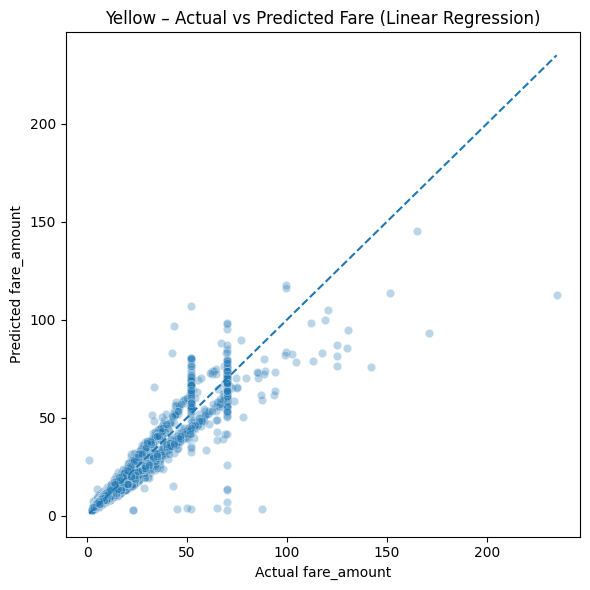

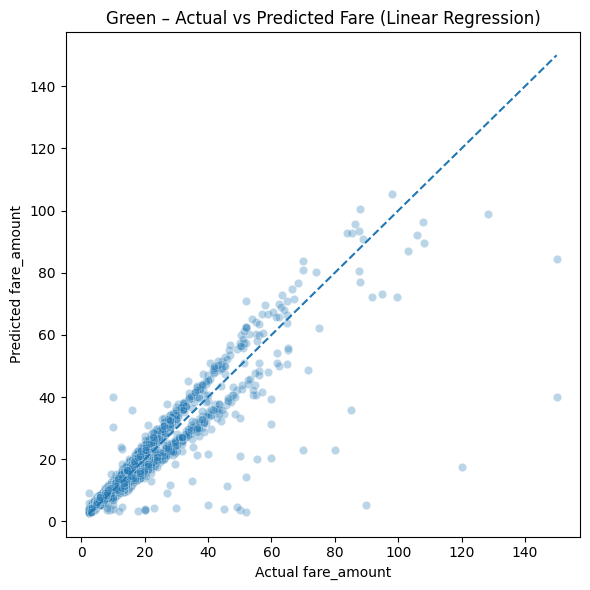

In [ ]:
# ============================================
# Task 6 – Step 3: Plot Actual vs Predicted Fare Amounts
# ============================================
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots display nicely in notebook
%matplotlib inline

# ---------------------------------------------
# Helper function to train LR and plot for one taxi type
# ---------------------------------------------
def plot_actual_vs_pred(train_df, test_df, taxi_type="Yellow"):
    from pyspark.ml.regression import LinearRegression

    print(f"\n[Task 6.3] Training LinearRegression for {taxi_type} (for plotting)...")
    lr = LinearRegression(featuresCol="features", labelCol="label")
    lr_model = lr.fit(train_df)
    preds = lr_model.transform(test_df).select("label", "prediction")

    # Sample a manageable fraction to convert to Pandas
    # (adjust fraction if needed depending on memory)
    if taxi_type == "Yellow":
        frac = 0.001   # ~0.1% of test set
    else:
        frac = 0.01    # ~1% of test set for Green (smaller dataset)

    preds_sample = preds.sample(withReplacement=False, fraction=frac, seed=42)

    print(f"[Task 6.3] Sampled rows for {taxi_type}: {preds_sample.count()}")

    pdf = preds_sample.toPandas()

    # Basic scatter plot: Actual vs Predicted
    plt.figure(figsize=(6, 6))
    sns.scatterplot(data=pdf, x="label", y="prediction", alpha=0.3)
    min_val = min(pdf["label"].min(), pdf["prediction"].min())
    max_val = max(pdf["label"].max(), pdf["prediction"].max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
    plt.xlabel("Actual fare_amount")
    plt.ylabel("Predicted fare_amount")
    plt.title(f"{taxi_type} – Actual vs Predicted Fare (Linear Regression)")
    plt.tight_layout()
    plt.show()

    return pdf

# ---------------------------------------------
# Run plots for Yellow and Green
# (uses train_y, test_y, train_g, test_g from Task 6)
# ---------------------------------------------
pdf_yellow = plot_actual_vs_pred(train_y, test_y, taxi_type="Yellow")
pdf_green  = plot_actual_vs_pred(train_g, test_g, taxi_type="Green")

### 6.4 How Well Do the Models Predict Fares?

Based on the RMSE, MAE, and R² values from the previous step:

- For **Yellow taxis**, the models achieve:
  - RMSE around **5.7–6.0**
  - MAE around **2.7–2.8**
  - R² around **0.85–0.86**
- For **Green taxis**, the models achieve:
  - RMSE around **6.3–6.5**
  - MAE around **2.6**
  - R² around **0.77–0.78**

This means that:

- On average, the absolute error in fare prediction is about **2.5–3 USD**, which is quite reasonable given the noise in real taxi trips.
- The R² scores show that the models explain a large proportion of the variance in fares, especially for Yellow taxis.

If I had more time, I would try to improve the model by:

- Adding more features (e.g. `PULocationID`, `DOLocationID`, interaction features, or time-of-day-based categories).
- Tuning hyperparameters of the tree-based models (max depth, number of trees, etc.).
- Trying other regressors such as Gradient Boosted Trees.
---

### 6.5 What I Learned and What I Would Do Differently

From this project, I learned:

- How to build a **full Spark pipeline** starting from raw Parquet files:
  downloading → cleaning → EDA → feature engineering → modeling.
- How much impact **data representation** (Parquet vs CSV) and **feature engineering** have on both performance and scalability.
- How to combine **PySpark SQL**, **DataFrame API**, and **Spark MLlib** in one coherent workflow.

If I were to approach this project again, I would:

- Design the feature engineering step more systematically from the start (e.g. thinking earlier about which columns to keep for modeling).
- Experiment with **model tuning** and **cross-validation** to squeeze out extra performance.
- Add geospatial or zone-level features if computational resources allow, to better capture location-dependent fare patterns.
